In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
folder_path = r'..\data\raw'
file_type = '/*csv'

files = glob.glob(folder_path + file_type)

latest_file = max(files, key=os.path.getctime)

df = pd.read_csv(latest_file)

## 1. Общие сведения о датасете.

In [3]:
df = df[df['price_byn'] > 1500]

In [4]:
print(f"Shape: {df.shape}")
print(f"Shape: {df.shape}")
print("--------------------")
print(df.isna().sum())
print("--------------------")
print(df.info())
print("--------------------")
print(df.describe())

Shape: (4007, 21)
Shape: (4007, 21)
--------------------
ad_id                    0
subject                  0
price_byn                0
company_ad               0
list_time                0
condition                0
brand                  455
processor             1358
rom_volume            2107
rom_type               816
diagonal              2166
os                     698
videocard             2577
videocard_brand       2712
region                   0
gaming_laptop         1273
matrix_type           2548
display_resolution    1154
ram_volume            2068
ram_type              2668
battery_life          2732
dtype: int64
--------------------
<class 'pandas.core.frame.DataFrame'>
Index: 4007 entries, 4 to 11748
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ad_id               4007 non-null   int64  
 1   subject             4007 non-null   object 
 2   price_byn           4007 non-null   fl

Очень много пропусков из 11800 объявлений всего в 700 заполнены все собранные нами данные.
Больше всего пропусков в бренде видеокарты. Хотя, параметр важный, возможно имеет смысл полностью от него избавиться.

In [5]:
df.dropna().shape

(518, 21)

In [6]:
df.nunique()

ad_id                 4007
subject               3607
price_byn             1818
company_ad               2
list_time             3255
condition                2
brand                   20
processor               26
rom_volume               5
rom_type                 8
diagonal                17
os                      10
videocard                3
videocard_brand         71
region                   7
gaming_laptop            2
matrix_type              4
display_resolution      12
ram_volume              10
ram_type                10
battery_life             6
dtype: int64

Будем работать только с ноутбуками дороже 100 рублей.

In [7]:
df['rom_type'].unique()

array(['SSD', nan, 'HDD', 'HDD + SSD', 'Прочее', 'SSHD',
       'SSD + Intel Optane', 'eMMC', 'SSHD + SSD'], dtype=object)

In [8]:
print("Новые размеры:", df.shape)
df.head()

Новые размеры: (4007, 21)


,ad_id,subject,price_byn,company_ad,list_time,condition,brand,processor,rom_volume,rom_type,...,os,videocard,videocard_brand,region,gaming_laptop,matrix_type,display_resolution,ram_volume,ram_type,battery_life
4,1063505978,Ноутбук Aorus 7,3300.0,False,2026-04-26T09:43:46Z,Б/у,Gigabyte,Intel Core i5,1000 Гб,SSD,...,NaN,Встроенная и дискретная,NVIDIA GeForce RTX 4050 6 ГБ,Брестская область,Да,NaN,NaN,32 Гб,NaN,NaN
5,1066441213,Macbook Air M1 16/256 Идеал,1600.0,False,2026-04-26T09:43:45Z,Б/у,Apple,Apple M1,256 ГБ,NaN,...,Mac OS,NaN,NaN,Минск,NaN,OLED,2560 х 1440,16 Гб,NaN,NaN
6,1066441075,MacBook Pro 16 M1 Pro 16GB/256 SSD,2900.0,False,2026-04-26T09:42:37Z,Б/у,Apple,Apple M1 Pro,256 ГБ,SSD,...,NaN,NaN,NaN,Минск,NaN,NaN,NaN,16 Гб,NaN,10 и более часов
10,1063326883,"MACBOOK AIR 13/15 M5 512GB, 1TB. НОВЫЕ. ОРИГИН...",3500.0,True,2026-04-26T09:40:30Z,Новое,Apple,NaN,NaN,NaN,...,NaN,NaN,NaN,Минск,NaN,NaN,NaN,NaN,NaN,NaN
11,1060883452,Игровой ноутбук LENOVO LOQ 15IAX9 83GS00R9RK ТОРГ,3050.0,False,2026-04-26T09:37:13Z,Б/у,Lenovo,Intel Core i5,512 Гб,SSD,...,Windows 10,Встроенная и дискретная,NVIDIA GeForce RTX 3050 6 ГБ,Витебская область,Да,IPS,1920 х 1080,24 Гб,DDR5,2-4 часа


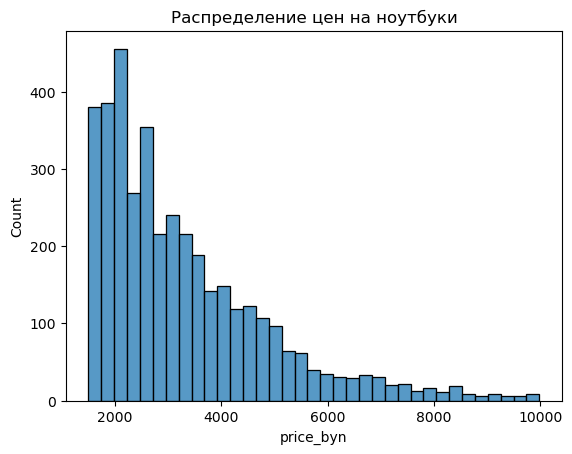

In [9]:
sns.histplot(data=df[df['price_byn'] < 10000], x = 'price_byn')

plt.title('Распределение цен на ноутбуки')

plt.show()

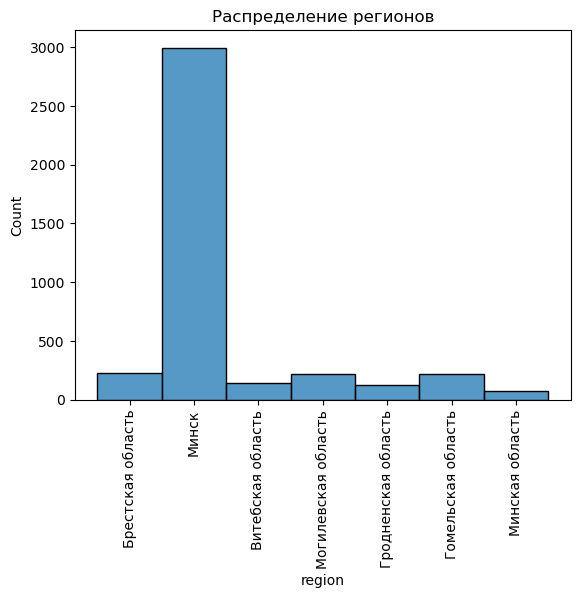

In [10]:
sns.histplot(data=df, x='region')
plt.title('Распределение регионов')
plt.xticks(rotation=90)
plt.show()

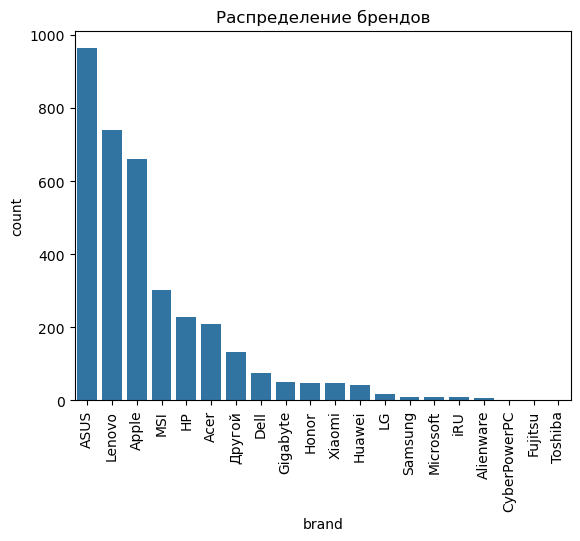

In [11]:
brand_order = df['brand'].value_counts().index
sns.countplot(data=df, x='brand', order=brand_order)
plt.title('Распределение брендов')
plt.xticks(rotation=90)
plt.show()

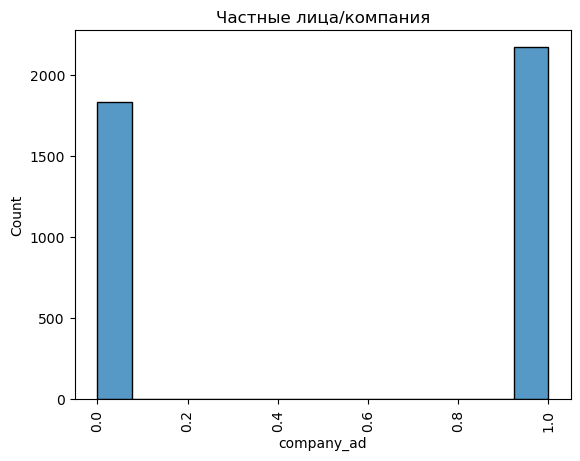

In [12]:
sns.histplot(data=df, x='company_ad')
plt.title('Частные лица/компания')
plt.xticks(rotation=90)
plt.show()

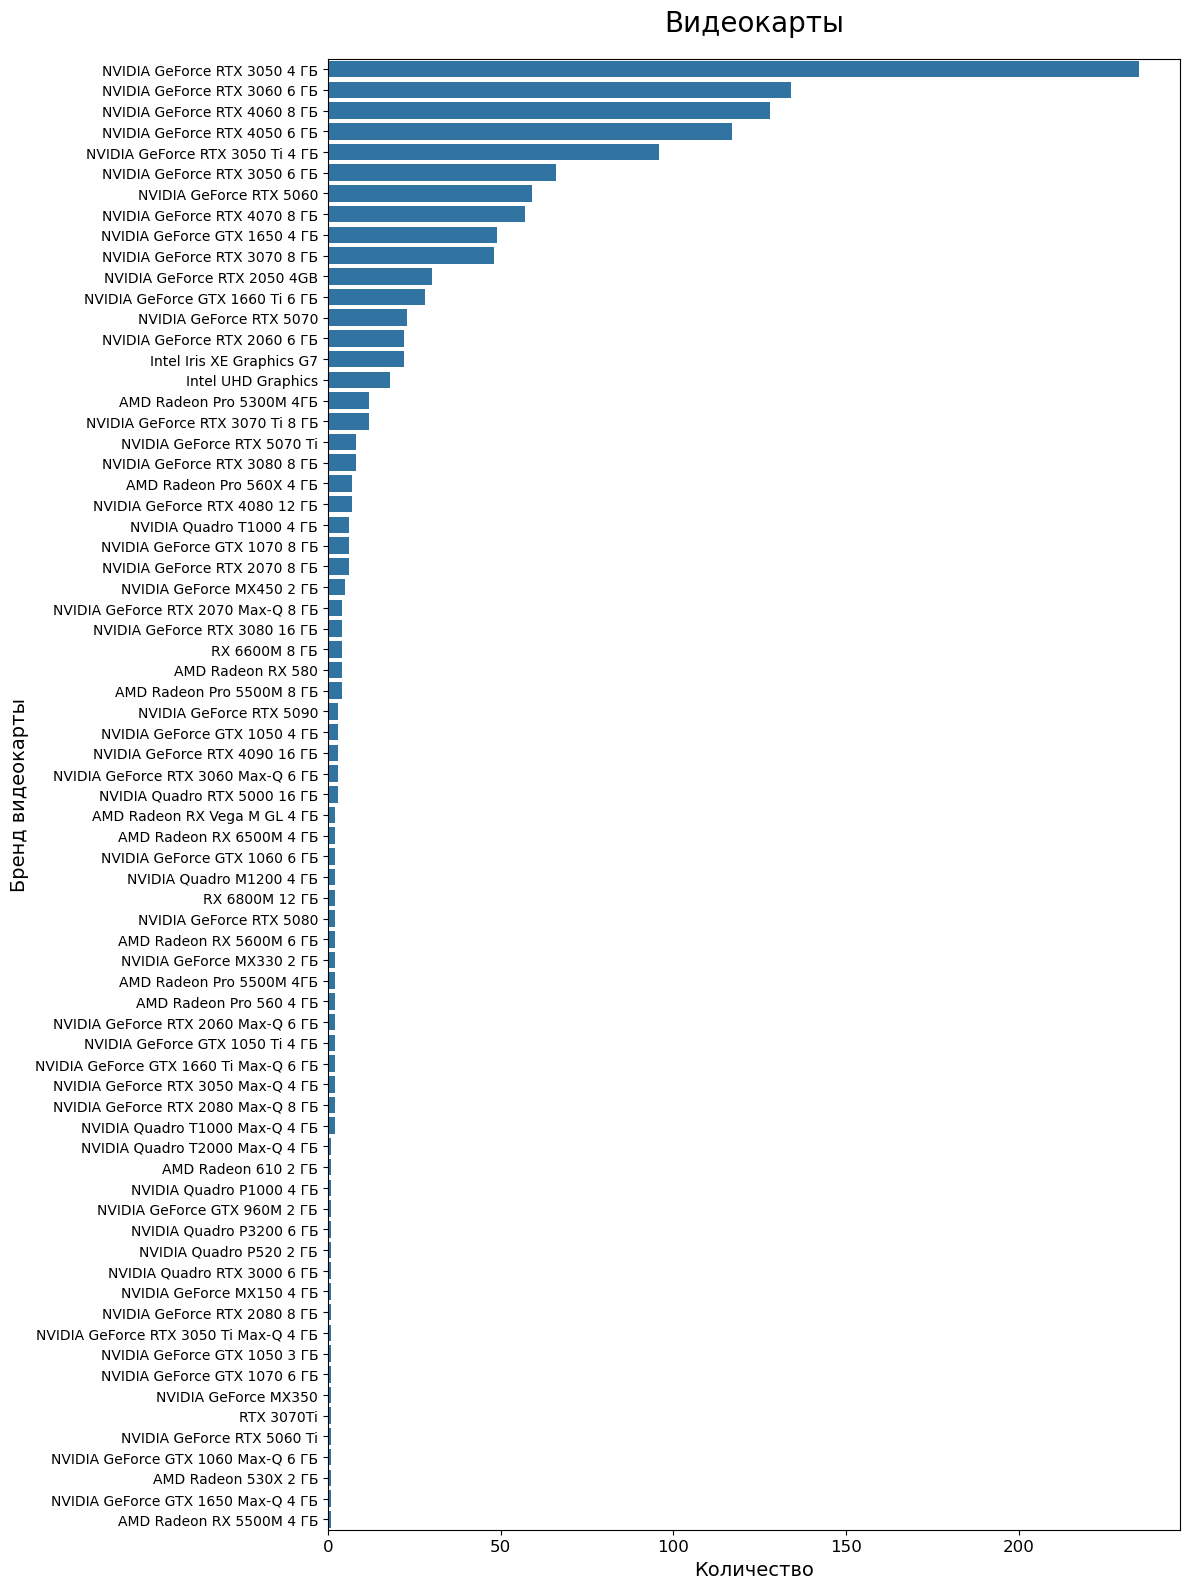

In [13]:
plt.figure(figsize=(12, 16))

order = df['videocard_brand'].value_counts().index

ax = sns.countplot(data=df, y='videocard_brand', order=order)

plt.title('Видеокарты', fontsize=20, pad=20)
plt.xlabel('Количество', fontsize=14)
plt.ylabel('Бренд видеокарты', fontsize=14)

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

Многие пользователи указали встроенную графику как дискретную видеокарту. Надо исправить.

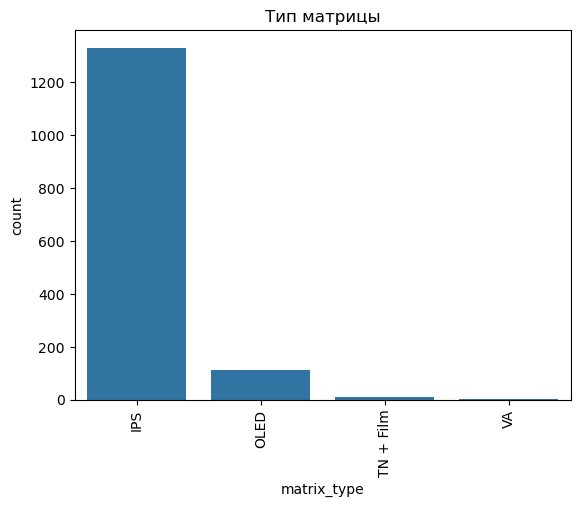

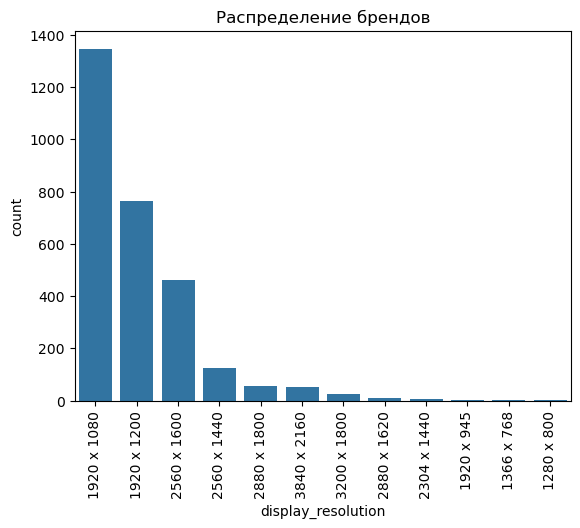

In [14]:
brand_order = df['matrix_type'].value_counts().index
sns.countplot(data=df, x='matrix_type', order=brand_order)
plt.title('Тип матрицы')
plt.xticks(rotation=90)
plt.show()

brand_order = df['display_resolution'].value_counts().index
sns.countplot(data=df, x='display_resolution', order=brand_order)
plt.title('Распределение брендов')
plt.xticks(rotation=90)
plt.show()

Слишком много значений разрешения. Возможно имеет смысл создать искусственный параметр число/плотность пикселей. Также можно нестандартные по соотношению матрицы включить или заменить более популярными значениями, схожими по качеству (например: 1920x945 на 1920x1080)

## 2. Заполнение пропущенных значений и обработка даных

In [15]:
binary_features = ['company_ad', 'condition', 'videocard', 'gaming_laptop']
categorial_features = ['brand', 'processor', 'rom_volume', 'processor', 'rom_type', 'os']

In [16]:
print(df.nunique())
print('==========================================')
print('Уникальные значения разлиычных параметров')
print(f'1. os: {df['os'].unique()}')
print(f'2. videocard: {df['videocard'].unique()}')
print(f'3. processor: {df['processor'].unique()}')
print(f'4. rom_type: {df['rom_type'].unique()}')
print(f'5. diagonal: {df['diagonal'].unique()}')
print(f'6. ram_volume: {df['ram_volume'].unique()}')
print(f'7. ram_type: {df['ram_type'].unique()}')
print(f'8. battery_life: {df['battery_life'].unique()}')
print(f'9. company_ad: {df['company_ad'].unique()}')

ad_id                 4007
subject               3607
price_byn             1818
company_ad               2
list_time             3255
condition                2
brand                   20
processor               26
rom_volume               5
rom_type                 8
diagonal                17
os                      10
videocard                3
videocard_brand         71
region                   7
gaming_laptop            2
matrix_type              4
display_resolution      12
ram_volume              10
ram_type                10
battery_life             6
dtype: int64
Уникальные значения разлиычных параметров
1. os: [nan 'Mac OS' 'Windows 10' 'Windows 11' 'без ОС' 'Прочее' 'OS X'
 'Windows Vista' 'DOS' 'Linux' 'Windows XP']
2. videocard: ['Встроенная и дискретная' nan 'Встроенная' 'Дискретная']
3. processor: ['Intel Core i5' 'Apple M1' 'Apple M1 Pro' nan 'Intel Core i7'
 'AMD Ryzen 5' 'AMD Ryzen 7' 'Apple M4' 'Другой' 'Intel Core i9'
 'Apple M2' 'Apple M3' 'AMD Ryzen 9' 'Apple M5 

In [17]:
df['videocard_brand'].unique()

array(['NVIDIA GeForce RTX 4050 6 ГБ', nan,
       'NVIDIA GeForce RTX 3050 6 ГБ', 'NVIDIA GeForce RTX 4060 8 ГБ',
       'NVIDIA GeForce RTX 3050 Ti 4 ГБ', 'NVIDIA GeForce RTX 3050 4 ГБ',
       'Intel UHD Graphics', 'NVIDIA GeForce RTX 2050 4GB',
       'NVIDIA GeForce GTX 1650 4 ГБ', 'AMD Radeon 610 2 ГБ',
       'NVIDIA Quadro P1000 4 ГБ', 'NVIDIA Quadro T1000 4 ГБ',
       'NVIDIA GeForce RTX 3060 6 ГБ', 'NVIDIA Quadro T2000 Max-Q 4 ГБ',
       'AMD Radeon Pro 5300M 4ГБ', 'NVIDIA GeForce RTX 3070 8 ГБ',
       'Intel Iris XE Graphics G7', 'NVIDIA GeForce RTX 5060',
       'NVIDIA GeForce RTX 2060 6 ГБ', 'NVIDIA Quadro RTX 5000 16 ГБ',
       'NVIDIA GeForce RTX 2070 Max-Q 8 ГБ',
       'NVIDIA GeForce RTX 4070 8 ГБ', 'NVIDIA GeForce RTX 5070',
       'NVIDIA GeForce GTX 1060 6 ГБ', 'NVIDIA GeForce RTX 3080 8 ГБ',
       'AMD Radeon RX Vega M GL 4 ГБ', 'NVIDIA GeForce RTX 3070 Ti 8 ГБ',
       'AMD Radeon Pro 560X 4 ГБ', 'NVIDIA GeForce RTX 5070 Ti',
       'AMD Radeon RX 6500M 4 Г

In [18]:
df['os'] = df['os'].replace({'OS X': 'Mac OS'}) #OS X is Mac OS

In [19]:
df['company_ad'] = df['company_ad'].astype(int)

In [20]:
import re


def extract_gpu(subject: str):
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')

    s = subject

    def find_mem(text: str) -> str | None:
        """
        Берёт VRAM сразу после модели.
        Если следом идёт ЕЩЁ одна память (16ГБ 1000ГБ) — это RAM+SSD, пропускаем.
        Если число > 32 — это точно не VRAM.
        """
        m = re.search(r'(\d+)\s*(?:ГБ|GB)', text[:30], re.IGNORECASE)
        if not m:
            return None
        if int(m.group(1)) > 32:
            return None
        tail = text[m.end():m.end() + 25]
        if re.search(r'\d+\s*(?:ГБ|GB|ТБ|TB)', tail, re.IGNORECASE):
            return None
        return m.group(0)

    def fmt(base: str, mem: str | None) -> str:
        return f"{base} {mem}" if mem else base

    SEP = r'[\s\-]*'   # разделитель: пробелы, дефисы или ничего

    if re.search(r'mac\s*book', s, re.IGNORECASE):
        return 0
    # ── Intel ─────────────────────────────────────────────────────────────
    m = re.search(r'Intel\s+Iris\s+Xe\s+Graphics\s+(G\d+)', s, re.IGNORECASE)
    if m:
        return f"Intel Iris XE Graphics {m.group(1).upper()}"
    if re.search(r'Intel\s+Iris\s+Xe', s, re.IGNORECASE):
        return 'Intel Iris XE Graphics'
    if re.search(r'Intel\s+UHD\s+Graphics', s, re.IGNORECASE):
        return 'Intel UHD Graphics'
    m = re.search(r'(?:Intel\s+)?Arc\s+(A\d{3}M?)', s, re.IGNORECASE)
    if m:
        return fmt(f"Intel Arc {m.group(1).upper()}", find_mem(s[m.end():]))

    # ── NVIDIA Quadro ─────────────────────────────────────────────────────
    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}RTX{SEP}(\d{{3,5}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro RTX {m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}T{SEP}(\d{{3,4}})\s*(Max-Q)?', s, re.IGNORECASE)
    if m:
        maxq = " Max-Q" if m.group(2) else ""
        return fmt(f"NVIDIA Quadro T{m.group(1)}{maxq}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}P{SEP}(\d{{3,4}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro P{m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}M{SEP}(\d{{3,4}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro M{m.group(1)}", find_mem(s[m.end():]))

    # ── NVIDIA GeForce RTX / GTX / MX ─────────────────────────────────────
    m = re.search(
        rf'(?:NVIDIA\s+)?(?:GeForce\s+)?RTX{SEP}(\d{{4}}){SEP}(Ti\b)?\s*(Max-Q)?',
        s, re.IGNORECASE
    )
    if m:
        ti   = " Ti"    if m.group(2) else ""
        maxq = " Max-Q" if m.group(3) else ""
        return fmt(f"NVIDIA GeForce RTX {m.group(1)}{ti}{maxq}", find_mem(s[m.end():]))

    m = re.search(
        rf'(?:NVIDIA\s+)?(?:GeForce\s+)?GTX{SEP}(\d{{4}}){SEP}(Ti\b)?\s*(Max-Q)?',
        s, re.IGNORECASE
    )
    if m:
        ti   = " Ti"    if m.group(2) else ""
        maxq = " Max-Q" if m.group(3) else ""
        return fmt(f"NVIDIA GeForce GTX {m.group(1)}{ti}{maxq}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?(?:GeForce\s+)?MX{SEP}(\d{{3,4}})', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA GeForce MX{m.group(1)}", find_mem(s[m.end():]))

    # ── AMD Radeon ────────────────────────────────────────────────────────
    m = re.search(r'(?:AMD\s+)?Radeon\s+RX\s+Vega\s+M\s+GL', s, re.IGNORECASE)
    if m:
        return fmt("AMD Radeon RX Vega M GL", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?Radeon\s+Pro{SEP}(\d{{3,4}}[A-Z]*)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon Pro {m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?(?:Radeon\s+)?RX{SEP}(\d{{3,4}}M?)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon RX {m.group(1).upper()}", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?Radeon{SEP}(\d{{3,4}}[A-Z]*)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon {m.group(1).upper()}", find_mem(s[m.end():]))
    




In [21]:
print(df[['subject', 'videocard_brand']].head(10).to_string())
df['videocard_brand'] = df['videocard_brand'].fillna(df['subject'].apply(extract_gpu))
print(df[['subject', 'videocard_brand']].head(10).to_string())

                                                          subject                  videocard_brand
4                                                 Ноутбук Aorus 7     NVIDIA GeForce RTX 4050 6 ГБ
5                                     Macbook Air M1 16/256 Идеал                              NaN
6                              MacBook Pro 16 M1 Pro 16GB/256 SSD                              NaN
10    MACBOOK AIR 13/15 M5 512GB, 1TB. НОВЫЕ. ОРИГИНАЛ. ГАРАНТИЯ.                              NaN
11              Игровой ноутбук LENOVO LOQ 15IAX9 83GS00R9RK ТОРГ     NVIDIA GeForce RTX 3050 6 ГБ
12                     ASUS TUF F15 i7-12700H RTX4060 16ГБ 1000ГБ     NVIDIA GeForce RTX 4060 8 ГБ
14    Lenovo Gaming 120Гц/i5-11300H/8GB/SSD-512GB/RTX-3050 Ti 4GB  NVIDIA GeForce RTX 3050 Ti 4 ГБ
15  ASUS TUF 17,3''/144Hz/i5-12500H 12*16/16GB/512GB/RTX-3050 4GB     NVIDIA GeForce RTX 3050 4 ГБ
16          Ноутбук Asus/R5-7520U *4/8*/8GB/SSD-512GB/Radeon 610M                              NaN
18        

In [22]:
df['videocard_brand'] = df['videocard_brand'].isna().sum()